In [3]:
import sys
import time
import serial
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Configuration
BAUD_RATE = 115200
DEFAULT_CURRENTS = [0.2, 0.4, 0.8, 1.0, 1.6, 0.0]

In [60]:
from helpers import findDevice

PORT_MINIPAR = None
PORT_REF = None


In [61]:

# Try auto-detection

print("\nScanning for reference sensor (TIA)...")
if not PORT_REF:
    PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2)
    with serial.Serial(PORT_REF) as ser:
        ser.write("\x02\x04".encode())
        ser.flush()
if not PORT_REF:
    print("Reference sensor not found. Set PORT_REF manually in next cell.")


print("Scanning for MiniPAR...")
if not PORT_MINIPAR:
    PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
if not PORT_MINIPAR:
    print("MiniPAR not found. Set PORT_MINIPAR manually in next cell.")




print(f"\nPORT_MINIPAR: {PORT_MINIPAR}")
print(f"PORT_REF: {PORT_REF}")



Scanning for reference sensor (TIA)...
Received message: raw REPL; CTRL-B to exit
>, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: 
raw REPL; CTRL-B to exit
>
Scanning for MiniPAR...
Received message: MicroPython v1.27.0 on 2025-12-09; Raspberry Pi Pico with RP2040
Type "help()" for more information.
>>> hello, port: /dev/ttyACM1
Received message: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
MiniPAR,1.1, port: /dev/ttyACM0
Found device at: /dev/ttyACM0, answer: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
MiniPAR,1.1


PORT_MINIPAR: /dev/ttyACM0
PORT_REF: /dev/ttyACM1


In [63]:
# read mini Par
def get_par(port, raw=False):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        if raw:
            ser.write("par_raw\n".encode())
        else:
            ser.write("par\n".encode())
        r = ser.readline()
        #print(r)

        return float(r.decode().strip())
        #print(r)



def getPAR_TIA(port):
    with serial.Serial(port) as ser:
        ser.flush()
        ser.write("getPAR()\r".encode())
        response = ser.readline()# skip echo
        #print(response)
        response = ser.readline()
        #print(response)
    return float(response)



print(getPAR_TIA(PORT_REF))

print(get_par(PORT_MINIPAR, raw=True))

19.247176
3.47


In [72]:

continue_calibration = True
X_list = []  # Spectral channels
y_list = []  # Reference PAR values
angle_list = []  # Corresponding angles

while continue_calibration:
    try:
        input_str = float(input("Enter angle: "))
    except ValueError:
        print("Exiting calibration.")
        break
    except KeyboardInterrupt:
        print("Calibration interrupted by user.")
        break
    
    par_tia = getPAR_TIA(PORT_REF)
    par_minipar = get_par(PORT_MINIPAR, raw=True)
    
    print(f"angle: {input_str} | TIA PAR: {par_tia:.2f} | MiniPAR raw: {par_minipar:.2f}")
    X_list.append(par_minipar)
    y_list.append(par_tia)
    angle_list.append(float(input_str))
    

angle: -90.0 | TIA PAR: 0.42 | MiniPAR raw: 0.01
angle: -67.5 | TIA PAR: 8.22 | MiniPAR raw: 1.31
angle: 5.0 | TIA PAR: 14.66 | MiniPAR raw: 2.58
angle: 5.0 | TIA PAR: 18.68 | MiniPAR raw: 3.39
angle: 6.0 | TIA PAR: 19.89 | MiniPAR raw: 3.66
angle: 7.0 | TIA PAR: 18.31 | MiniPAR raw: 3.29
angle: 4.0 | TIA PAR: 14.02 | MiniPAR raw: 2.41
angle: 5.0 | TIA PAR: 7.35 | MiniPAR raw: 1.12
angle: 6.0 | TIA PAR: 0.05 | MiniPAR raw: 0.00
Exiting calibration.


[0.01, 1.31, 2.58, 3.39, 3.66, 3.29, 2.41, 1.12, 0.0]
[0.4178984, 8.216131, 14.657078, 18.679582, 19.888804, 18.309414, 14.015451, 7.352403, 0.047729136]
[-90.0, -67.5, -45.0, -22.5, 0.0, 22.5, 45.0, 67.5, 90.0]


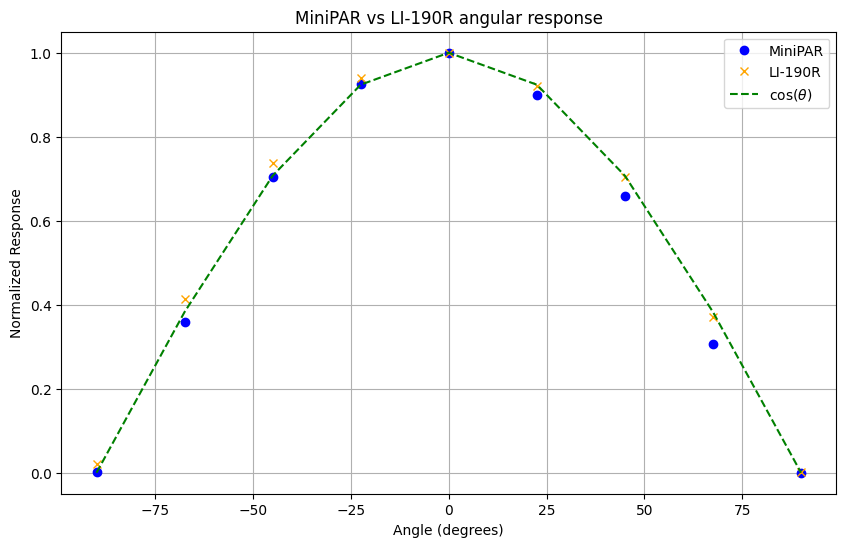

In [106]:
print(X_list)
print(y_list)
print(angle_list)
name = "angular_calbration_Vertical_2"
#angle_list = [-67.5, -45.0, -22.5, 0.0, 22.5, 45.0, 67.5]
angle_list = [-90.0, -67.5, -45.0, -22.5, 0.0, 22.5, 45.0, 67.5, 90.0]

plt.figure(figsize=(10, 6))
plt.plot(angle_list, [x / max(X_list) for x in X_list], 'o', label='MiniPAR', color='blue')
plt.plot(angle_list, [y / max(y_list) for y in y_list], 'x', label='LI-190R', color='orange')
plt.plot(angle_list, [np.cos(np.radians(a + 0)) for a in angle_list], label=r'cos($\theta$)', color='green', linestyle='--')
plt.xlabel('Angle (degrees)')
plt.ylabel('Normalized Response')
plt.title('MiniPAR vs LI-190R angular response')
plt.legend()
plt.grid()

plt.savefig(f"{name}.png", dpi=300, bbox_inches='tight')
csv_data = np.column_stack((angle_list, X_list, y_list))
np.savetxt(f"{name}.csv", csv_data, delimiter=",", header="Angle,MiniPAR,TIA", comments="") 


0

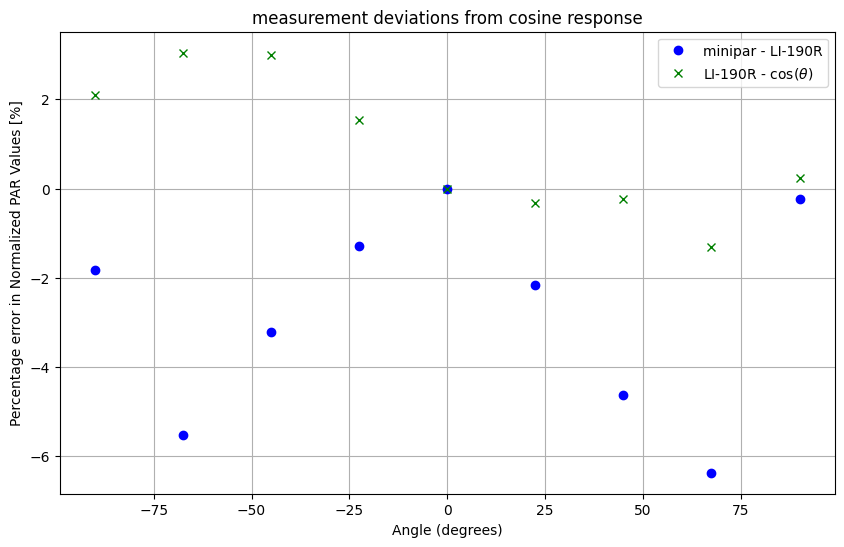

In [ ]:
plt.figure(figsize=(10, 6))
import operator

par_minipar_normalized = [100 * x / max(X_list) for x in X_list]
par_tia_normalized = [100 * y / max(y_list) for y in y_list]


#plt.plot(angle_list, list(map(operator.sub, par_minipar_normalized, par_tia_normalized)), 'o', label=r'minipar - cos($\theta$)', color='blue')
plt.plot(angle_list, list(map(operator.sub, par_minipar_normalized, par_tia_normalized)), 'o', label=r'minipar - LI-190R', color='blue')

plt.plot(angle_list, list(map(operator.sub,  par_tia_normalized, [100 * np.cos(np.radians(a )) for a in angle_list])),'x', label=r'LI-190R - cos($\theta$)', color='green') 
plt.xlabel('Angle [degrees]')
plt.ylabel('Percentage error in Normalized PAR Values [%]')
plt.title('measurement deviations from cosine response')
plt.legend()
plt.grid()

plt.savefig(f"{name}_deviations.png", dpi=300, bbox_inches='tight')
0